In [1]:
import pandas as pd
from sklearn.cluster import KMeans

In [2]:
df=pd.read_csv("Telco_churn.csv")

In [3]:
df.head()

,Unnamed: 0,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24,TenureGroup_24-48,TenureGroup_48-60,TenureGroup_60-72
0,0,0,1,29.85,29.85,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
1,1,0,34,56.95,1889.50,0,1,0,0,1,...,1,0,0,0,0,1,0,1,0,0
2,2,0,2,53.85,108.15,1,1,0,0,1,...,0,0,1,0,0,1,0,0,0,0
3,3,0,45,42.30,1840.75,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,4,0,2,70.70,151.65,1,0,0,0,1,...,0,0,1,0,1,0,0,0,0,0


In [4]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [6]:
# Since the dataset doesn't explicitly states reason for churn, clustering on churn customers might bring some insights

churn_df=df[df["Churn"]==1]

In [7]:
churn_df.shape

(1869, 36)

In [8]:
churn_df.columns

Index(['Unnamed: 0', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'TenureGroup_12-24', 'TenureGroup_24-48', 'TenureGroup_48-60',
       'TenureGroup_60-72'],
      dtype='object')

In [9]:
churn_df=churn_df.drop("Unnamed: 0",axis=1)

In [10]:
# From EDA, the key churn drivers are:
# contract type, tenure, monthly charges, additional services like tech support

In [11]:
cluster_features=churn_df[[
    'tenure', 'MonthlyCharges','TotalCharges', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes',  'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
]
    
]

In [12]:
cluster_features.shape

(1869, 19)

In [12]:
cluster_features.dtypes

tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int64
Contract_One year                          int64
Contract_Two year                          int64
PaperlessBilling_Yes                       int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Electronic check             int64
PaymentMethod_Mailed check                 int64
dtype: object

In [13]:
# Since the features like tenure, monthly charge are numerical with varied ranges, let's do some scaling

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled_features=scaler.fit_transform(cluster_features)

In [14]:
scaled_features.shape

(1869, 19)

In [15]:
type(scaled_features)

numpy.ndarray

In [16]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
kmeans.fit(scaled_features)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [17]:
# Finding optimal number of clusters using Elbow Method

inertia=[]
for k in range(1,11):
    model=KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(scaled_features)
    inertia.append(model.inertia_)

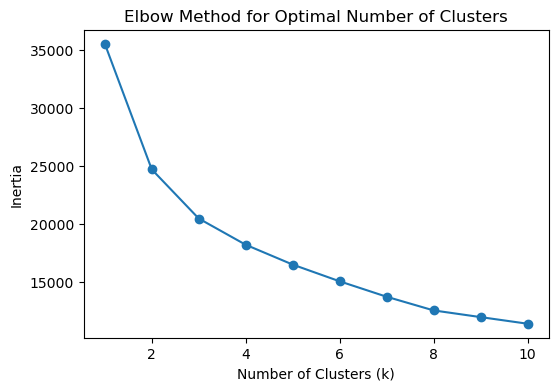

In [18]:
import matplotlib.pyplot as plt

k_values=range(1,len(inertia)+1)

plt.figure(figsize=(6,4))
plt.plot(k_values,inertia,marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.show()


In [19]:
# 3 or 4 clusters is ideal as the drop stabilizes 

In [20]:
# Using silhouette score

from sklearn.metrics import silhouette_score

silhouette_scores=[]

for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=model.fit_predict(scaled_features)
    score=silhouette_score(scaled_features,labels)
    silhouette_scores.append(score)

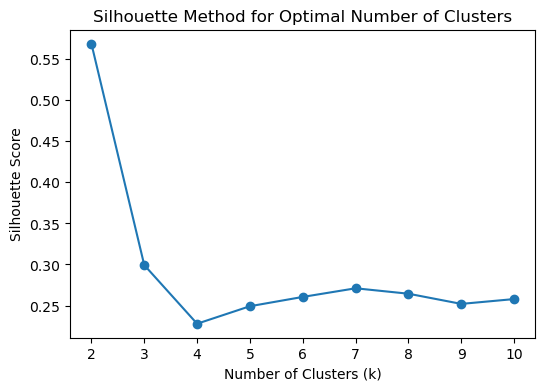

In [21]:
k_values=range(2,11)

plt.figure(figsize=(6,4))
plt.plot(k_values,silhouette_scores,marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal Number of Clusters")
plt.show()

In [22]:
# Silhouette analysis showed highest score at k=2, indicating strong seperation between broad groups.
# However, using only two clusters results in overly coarse segmentation and limits interpretability

# Therefore, k=3 was selected as it provides a balance between cluster seperation and meaningful segmentation

In [23]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
clusters=kmeans.fit_predict(scaled_features)
churn_df["Cluster"]=clusters

In [24]:
churn_df["Cluster"].value_counts()

Cluster
1    1319
0     437
2     113
Name: count, dtype: int64

In [25]:
churn_df.groupby("Cluster").mean()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24,TenureGroup_24-48,TenureGroup_48-60,TenureGroup_60-72
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.292906,45.878719,93.494279,4313.130320,1.0,0.514874,0.594966,0.237986,0.947368,0.052632,...,0.329519,0.098398,0.794050,0.244851,0.471396,0.059497,0.080092,0.441648,0.249428,0.210526
1,0.260045,9.570129,72.761372,726.638362,1.0,0.491281,0.288097,0.147081,0.888552,0.111448,...,0.009856,0.000000,0.766490,0.087945,0.644428,0.159970,0.189538,0.095527,0.004549,0.000000
2,0.044248,8.238938,20.368142,173.919912,1.0,0.504425,0.256637,0.247788,1.000000,0.000000,...,0.079646,0.044248,0.371681,0.079646,0.132743,0.628319,0.079646,0.053097,0.044248,0.008850


In [26]:
churn_df.groupby("Cluster")[["tenure","MonthlyCharges","TotalCharges"]].describe()

tenure                                                     \
          count       mean        std  min   25%   50%   75%   max   
Cluster                                                              
0         437.0  45.878719  15.697438  2.0  35.0  47.0  58.0  72.0   
1        1319.0   9.570129  10.281813  1.0   2.0   5.0  14.0  59.0   
2         113.0   8.238938  13.908036  1.0   1.0   1.0   9.0  61.0   

        MonthlyCharges             ...                  TotalCharges  \
                 count       mean  ...      75%     max        count   
Cluster                            ...                                 
0                437.0  93.494279  ...  104.750  118.35        437.0   
1               1319.0  72.761372  ...   88.225  106.90       1319.0   
2                113.0  20.368142  ...   20.350   25.90        113.0   

                                                                               
                mean          std     min       25%      50%      75%     max  
Cluster                                                                        
0        4313.130320  1764.514887  180.25  2917.500  4213.35  5624.85  8684.8  
1         726.638362   811.140973   23.45    90.975   389.60  1093.80  4364.1  
2         173.919912   296.409147   18.85    20.050    21.00   178.50  1334.0  

[3 rows x 24 columns]

In [27]:
categorical_cols=['InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes',  'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

for col in categorical_cols:
    print(f"\nDistribution of {col} within each cluster : \n")
    print(churn_df.groupby("Cluster")[col].value_counts(normalize=True))


Distribution of InternetService_Fiber optic within each cluster : 

Cluster  InternetService_Fiber optic
0        1                              0.837529
         0                              0.162471
1        1                              0.705838
         0                              0.294162
2        0                              1.000000
Name: proportion, dtype: float64

Distribution of InternetService_No within each cluster : 

Cluster  InternetService_No
0        0                     1.0
1        0                     1.0
2        1                     1.0
Name: proportion, dtype: float64

Distribution of OnlineSecurity_No internet service within each cluster : 

Cluster  OnlineSecurity_No internet service
0        0                                     1.0
1        0                                     1.0
2        1                                     1.0
Name: proportion, dtype: float64

Distribution of OnlineSecurity_Yes within each cluster : 

Cluster  OnlineSecurity_

In [28]:
### INSIGHTS

# Cluster 0 - High Value, Long Tenure churners
# These customers stayed long with company, paid high monthly charges, accumulated high total revenue
# This is usually price dissatisfaction or competitor switching
# High-Value Dissatisfied Customers

# Cluster 1 - Early churners with Moderate Spending
# Most of them leave within the first year and has month to month contracts
# This suggests early dissatisfaction or poor onboarding experience
# This is the largest cluster meaning most churn happens early

# Cluster 2 - Low Value, Basic Service Churners
# These customers pay very low monthly charges, strongly prefer mailed check payments, use basic services
# This usually indicates traditional users or ones with low digital services engagement
# Low-Engagement Basic Users

In [29]:
# Visualizing Clusters

from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_components=pca.fit_transform(scaled_features)

In [30]:
plt_df=pd.DataFrame(pca_components,columns=["PCA1","PCA2"])
plt_df["Cluster"]=clusters

centroids=kmeans.cluster_centers_
centroids_pca=pca.transform(centroids)

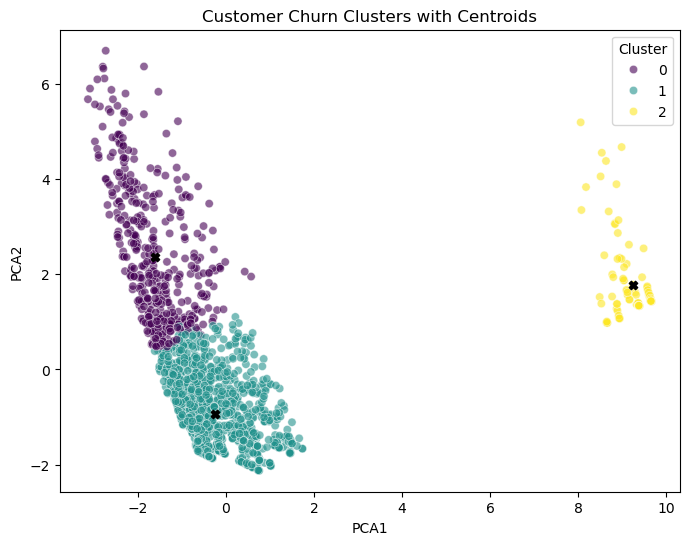

In [31]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=plt_df,x="PCA1",y="PCA2",hue="Cluster",palette="viridis",alpha=0.6)
plt.scatter(centroids_pca[:,0],centroids_pca[:,1],marker="X",c="black",label="Centroids")
plt.title("Customer Churn Clusters with Centroids")
plt.show()

In [32]:
pca.explained_variance_ratio_

array([0.32952952, 0.15883638])

In [33]:
# The chosen components explain about 48% of the total variance, providing a reasonable representation
# Based on the plot, cluster 2 seperates primarily along the first component, indicating differences in key behavioral features
# Cluster 1 and Cluster 0 are differentiated along the second principal components

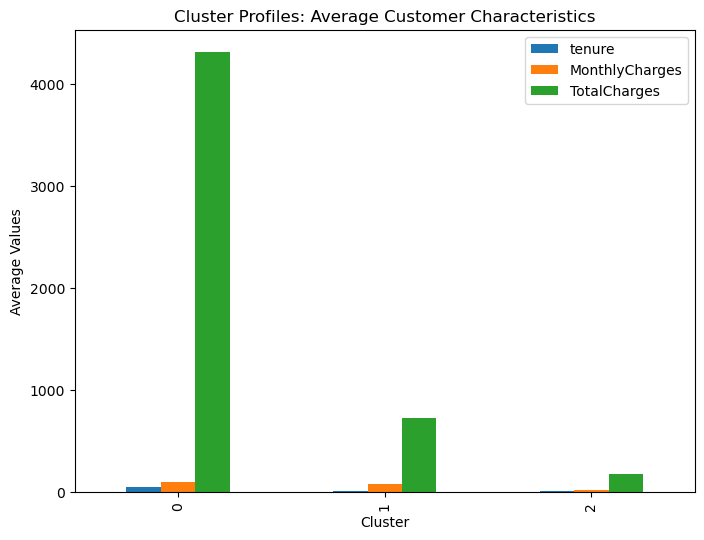

In [34]:
# Cluster Profile Bar Chart

cluster_profile=churn_df.groupby("Cluster")[["tenure","MonthlyCharges","TotalCharges"]].mean()
cluster_profile.plot(kind="bar",figsize=(8,6))
plt.title("Cluster Profiles: Average Customer Characteristics")
plt.ylabel("Average Values")
plt.show()

In [35]:
# Total Charges shows the largest variation across clusters because it reflects cumulative spending over time

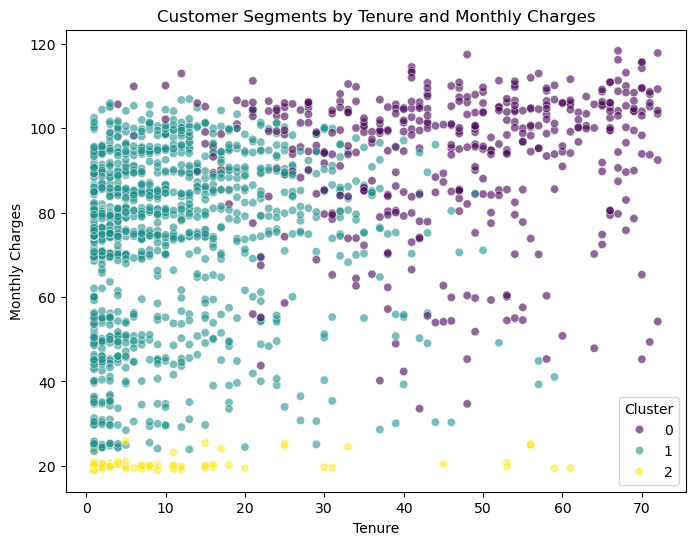

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=churn_df,x="tenure",y="MonthlyCharges",hue="Cluster",palette="viridis",alpha=0.6)
plt.title("Customer Segments by Tenure and Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

In [37]:
# Cluster 0- High service or Premium users who churn at different points
# Cluster 1- Early lifecycle churners
# Cluster 2- Low cost basic users

In [38]:
### CONCLUSION

# This analysis applied K-Means Clustering to segment customers who have churned into meaningful behavioral groups
# The optimal number of clusters was determined using the elbow method and silhouette score analysis
# Cluster interpretation using tenure, monthly charges, total charges, and service-related variables revealed clear differences

# The first segment consists of long-tenure, high-spending customers who eventually leave despite significant lifetime value
# The second and largest segment includes customers who churn early in their life cycle with moderate service usage
# The third segment represents low-value customers with basic service plans and minimal spending

# Visualization through PCA Projections and tenure-monthly charge scatter plots confirmed the separation between these segments
# The clustering structure suggests that customer churn is influenced by both pricing tiers and lifecycle duration

# From a business perspective, these findings indicate that churn reduction strategies should be segment-specific
# Early-tenure customers may benefit from improved service engagement
# High-value, long-term customers may require targeted retention programs
# Low-value basic users may require pricing or service adjustments to improve engagement

# Overall, customer segmentation provides actionable insights into churn behavior and highlights opportunities for more targeted strategies